In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Load the file safely from Google Drive
file_path = '/content/drive/My Drive/Passanger_booking_data.csv'
df = pd.read_csv(file_path)

# Print safe, clean metrics
print("Total Rows:", len(df))
print("Columns available:", list(df.columns))

Mounted at /content/drive
Total Rows: 50002
Columns available: ['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_day', 'route', 'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration', 'booking_complete']


In [3]:
# 1. Calculate overall booking conversion rate
total_bookings = len(df)
completed_bookings = df['booking_complete'].sum()
conversion_rate = (completed_bookings / total_bookings) * 100

print(f"--- 1. OVERALL CONVERSION ---")
print(f"Total Users: {total_bookings}")
print(f"Completed Bookings: {completed_bookings}")
print(f"Overall Conversion Rate: {conversion_rate:.2f}%\n")

# 2. Compare Sales Channels (Internet vs Mobile)
channel_perf = df.groupby('sales_channel')['booking_complete'].agg(
    Total_Users='count',
    Successful_Bookings='sum'
)
channel_perf['Conversion_Rate_%'] = (channel_perf['Successful_Bookings'] / channel_perf['Total_Users']) * 100
print(f"--- 2. PERFORMANCE BY SALES CHANNEL ---")
print(channel_perf)

--- 1. OVERALL CONVERSION ---
Total Users: 50002
Completed Bookings: 7479
Overall Conversion Rate: 14.96%

--- 2. PERFORMANCE BY SALES CHANNEL ---
               Total_Users  Successful_Bookings  Conversion_Rate_%
sales_channel                                                     
Internet             44383                 6870          15.478900
Mobile                5619                  609          10.838227


/tmp/ipykernel_5518/3836685034.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=channels, y=conversion_rates, palette=['#1f77b4', '#aec7e8'])


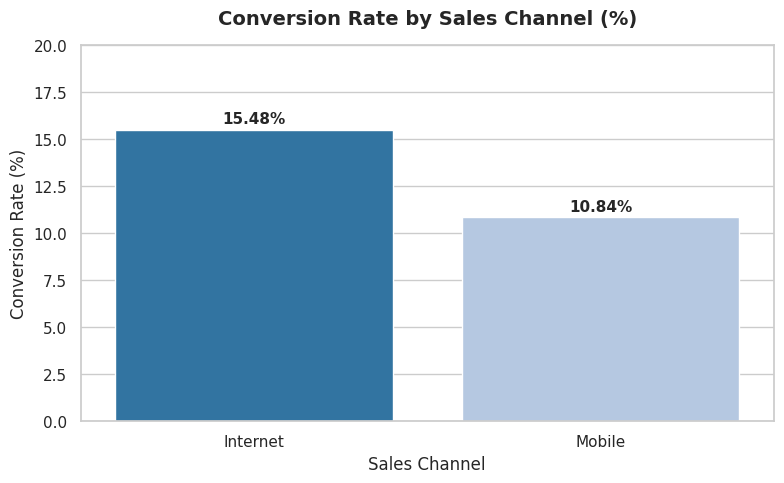

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Data for plotting
channels = ['Internet', 'Mobile']
conversion_rates = [15.48, 10.84]

# Create bar plot
ax = sns.barplot(x=channels, y=conversion_rates, palette=['#1f77b4', '#aec7e8'])
plt.title('Conversion Rate by Sales Channel (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sales Channel', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.ylim(0, 20)

# Add data labels on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
# This saves the chart to your Colab session so you can download it
plt.savefig('channel_conversion_comparison.png', dpi=300)
plt.show()

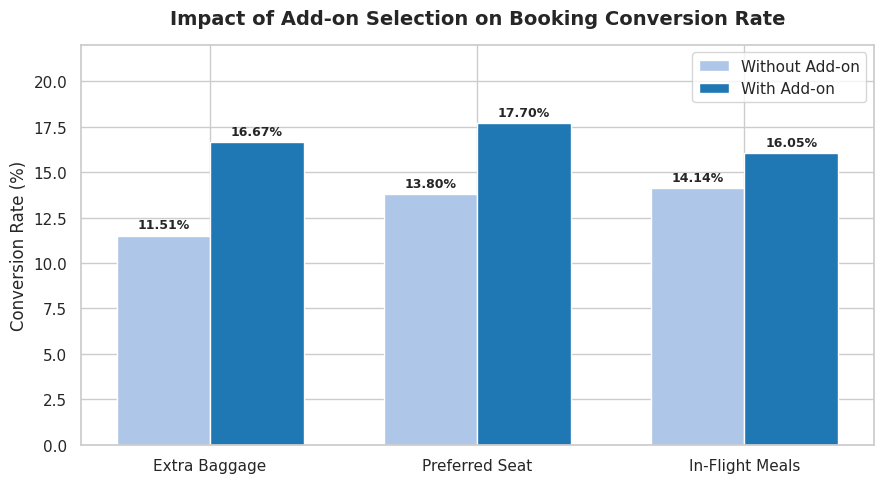

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")

addons = ['Extra Baggage', 'Preferred Seat', 'In-Flight Meals']
with_addon = [16.67, 17.70, 16.05]
without_addon = [11.51, 13.80, 14.14]

x = range(len(addons))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar([i - width/2 for i in x], without_addon, width, label='Without Add-on', color='#aec7e8')
rects2 = ax.bar([i + width/2 for i in x], with_addon, width, label='With Add-on', color='#1f77b4')

ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Impact of Add-on Selection on Booking Conversion Rate', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(addons, fontsize=11)
ax.legend()
ax.set_ylim(0, 22)

# Function to add text labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
# Saves the chart to your Colab session
plt.savefig('addon_conversion_comparison.png', dpi=300)
plt.show()